# [Deep Agents - Subagents & Workflow](https://docs.langchain.com/oss/python/deepagents/subagents)


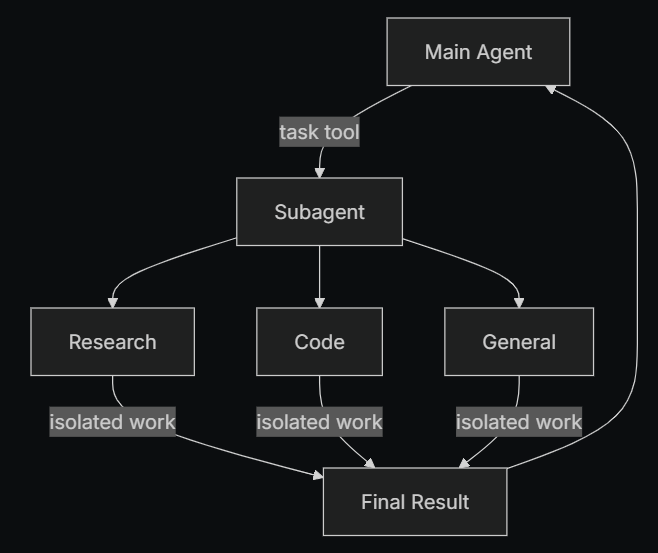

## 1. Subagent란 무엇인가?


### Subagent의 필요성

복잡한 작업을 처리할 때, 하나의 Agent가 모든 것을 처리하면:
- 컨텍스트가 너무 커져서 관리하기 어려움
- 각 작업에 대한 전문성이 떨어짐
- 에러 발생 시 전체 시스템이 영향을 받음


### Subagent의 장점

1. **Context Isolation (컨텍스트 격리)**
   - 각 Subagent는 자신의 작업에만 집중
   - 메인 Agent의 컨텍스트가 깨끗하게 유지됨

2. **역할 분리 (Role Separation)**
   - 각 Subagent는 특정 작업에 전문화
   - 더 나은 성능과 정확도

3. **재사용성 (Reusability)**
   - Subagent를 여러 프로젝트에서 재사용 가능
   - 모듈화된 구조로 유지보수 용이

## 2. Setup

### 환경 변수 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [LangSmith API Key](https://smith.langchain.com/)
- [Tavily API Key](https://tavily.com/) - 실제 웹 검색 기능 사용

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

### LLM 정의 

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)


### Checkpointer 정의

In [3]:
# Checkpointer 임포트 및 생성
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
print("Checkpointer가 생성되었습니다!")

Checkpointer가 생성되었습니다!


## 3. Dictionary-based Subagent 방식 

가장 간단한 방법은 딕셔너리로 Subagent를 정의하는 것입니다.


### Subagent by Dictionary 정의

#### 시니어 코드 리뷰어

In [4]:
code_reviewer = {
    "name": "code_reviewer",
    "description": "코드 품질과 베스트 프랙티스를 검토하는 전문가",
    "system_prompt": """
당신은 시니어 코드 리뷰어입니다.
- 코드의 품질을 검토합니다
- 버그와 개선점을 찾습니다
- 구체적인 피드백을 제공합니다
- 코딩 표준 준수 여부를 확인합니다
    """
}

#### 보안 전문가

In [5]:
security_expert = {
    "name": "security_expert",
    "description": "보안 취약점을 찾고 보안 개선 방안을 제시하는 전문가",
    "system_prompt": """
당신은 보안 전문가입니다.
- 보안 취약점을 찾습니다
- 보안 베스트 프랙티스를 적용합니다
- 위험도를 평가합니다
- 보안 개선 방안을 제시합니다
    """
}

#### 성능 최적화 전문가

In [6]:
performance_expert = {
    "name": "performance_expert",
    "description": "성능 병목과 최적화 방안을 제시하는 전문가",
    "system_prompt": """
당신은 성능 최적화 전문가입니다.
- 성능 병목 지점을 찾습니다
- 최적화 방안을 제시합니다
- 리소스 사용을 분석합니다
- 성능 개선 권장사항을 제공합니다
    """
}

### Deep Agent with Subagents

In [7]:
from deepagents import create_deep_agent

# Subagent들을 사용하는 Main Agent 생성
code_review_coordinator = create_deep_agent(
    model=llm,
    checkpointer=checkpointer,
    system_prompt="""
당신은 전문적인 '코드 리뷰 조정자(Coordinator)'입니다. 
당신의 주된 임무는 제공된 코드에 대해 하위 전문가(Subagents)들의 분석을 모두 수렴하여 최종 보고서를 작성하는 것입니다.

[필수 실행 프로세스]
분석을 시작할 때, 반드시 아래의 Subagent들을 순차적 혹은 병렬로 호출하여 의견을 먼저 구해야 합니다:
1. **code_reviewer**: 전반적인 코드 품질, 가독성, 컨벤션 및 로직 검토 요청.
2. **security_expert**: 취약점 점검, 데이터 노출 위험 등 보안 검토 요청.
3. **performance_expert**: 실행 시간, 메모리 효율성 및 최적화 방안 분석 요청.

[최종 보고서 구성 가이드]
1. 각 Subagent가 제출한 핵심 피드백을 누락 없이 요약하세요.
2. 전문가들 사이의 의견이 충돌할 경우, 조정자로서 가장 합리적인 우선순위를 결정하여 제시하세요.
3. 모든 피드백을 통합하여, 사용자가 즉시 적용할 수 있는 '최종 개선 코드'를 포함하세요.

반드시 모든 전문가(Subagents)의 분석 결과를 먼저 확인한 후 답변을 생성하십시오.
    """,
    subagents=[code_reviewer, security_expert, performance_expert]
)

print("Main Agent (with Subagents) 생성 완료!")


Main Agent (with Subagents) 생성 완료!


### Display

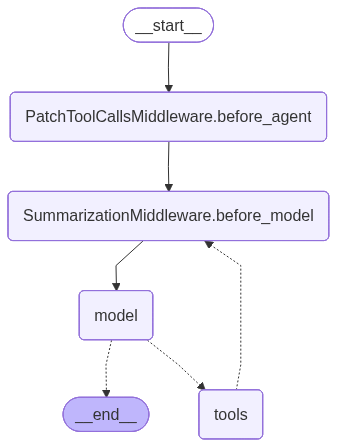

In [8]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            code_review_coordinator.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

### 테스트 


In [9]:
# 리뷰할 샘플 코드
sample_code = '''
def process_user_data(user_input):
    # 사용자 데이터 처리
    query = "SELECT * FROM users WHERE id = " + user_input
    result = execute_query(query)
    
    # 전체 데이터를 메모리에 로드
    all_data = []
    for item in result:
        all_data.append(item)
        # 각 항목마다 복잡한 연산 수행
        for i in range(1000000):
            x = i * i
    
    return all_data

def get_user_password(username):
    # 비밀번호를 평문으로 저장
    passwords = {
        "admin": "admin123",
        "user": "password"
    }
    return passwords.get(username)
'''

In [10]:
from langchain.messages import HumanMessage

review_request = f"""
다음 Python 코드를 종합적으로 리뷰해주세요:

```python
{sample_code}
```

각 전문가의 관점에서 검토하고, 
'code_review_report.txt' 파일에 다음 내용을 포함한 보고서를 작성해주세요:
1. 코드 품질 리뷰
2. 보안 분석
3. 성능 분석
4. 종합 개선 권장사항
5. 우선순위별 액션 아이템
"""

response = code_review_coordinator.invoke(
    {"messages": [HumanMessage(content=review_request)]},
    config={"configurable": {"thread_id": "code-review-demo"}}
)


In [11]:
print("작업 완료!")
print(response["messages"][-1].content)


작업 완료!
다음은 요청하신 대로, 제공하신 Python 코드에 대한 3명의 Subagents의 분석을 수렴한 최종 보고서입니다. 보고서는 code_reviewer, security_expert, performance_expert의 핵심 피드백을 반영하고, 서로 충돌하는 부분은 제 위치에서 합리적으로 조정했습니다. 또한 사용자가 바로 적용할 수 있는 최종 개선 코드도 포함했습니다.

코드 요약 분석 대상
- 대상 코드
  - def process_user_data(user_input): 쿼리 문자열을 직접 연결하는 SQL 실행 흐름
  - def get_user_password(username): 평문 비밀번호를 하드코딩한 패턴
- 주요 이슈로 확인된 포인트
  - SQL 인젝션 취약점
  - 비밀정보의 코드 내 하드코딩
  - 대용량 데이터의 메모리 로드 및 CPU 과다 사용 루프
  - 타입 힌트, 오류 처리, 로깅 부재
  - API 문서화의 부재

1) 코드 품질 리뷰 (code_reviewer 관점)
핵심 피드백 요약
- SRP 위반 및 모듈화 부족
  - process_user_data가 입력 처리, 데이터 조회, 결과 집계의 여러 역할을 한 함수에서 수행
- 안전하지 않은 문자열 SQL 구성
  - 문자열 연결로 구성된 쿼리로 인해 가독성은 좋으나 보안 취약점이 존재
- 큰 데이터용 메모리 로드 및 CPU 바운드 루프
  - result를 전체 로드하고, 아이템마다 1,000,000번의 루프를 수행하는 구조는 메모리/CPU 낭비
- 보안 미비
  - 비밀번호를 코드에 평문으로 하드코딩하는 패턴
- 가독성 및 문서화
  - 주석은 한국어로 되어 있지만, 함수의 public API에 대한 docstring이 부족
  - 타입 힌트 부재로 정적 분석 및 유지보수에 불리
- 예시: Before/After 제안
  - process_user_data를 단일 책임으로 나눌 것 (parsing, validation, fetch, transform)
  - ge

#### [Langsmith](https://smith.langchain.com/)

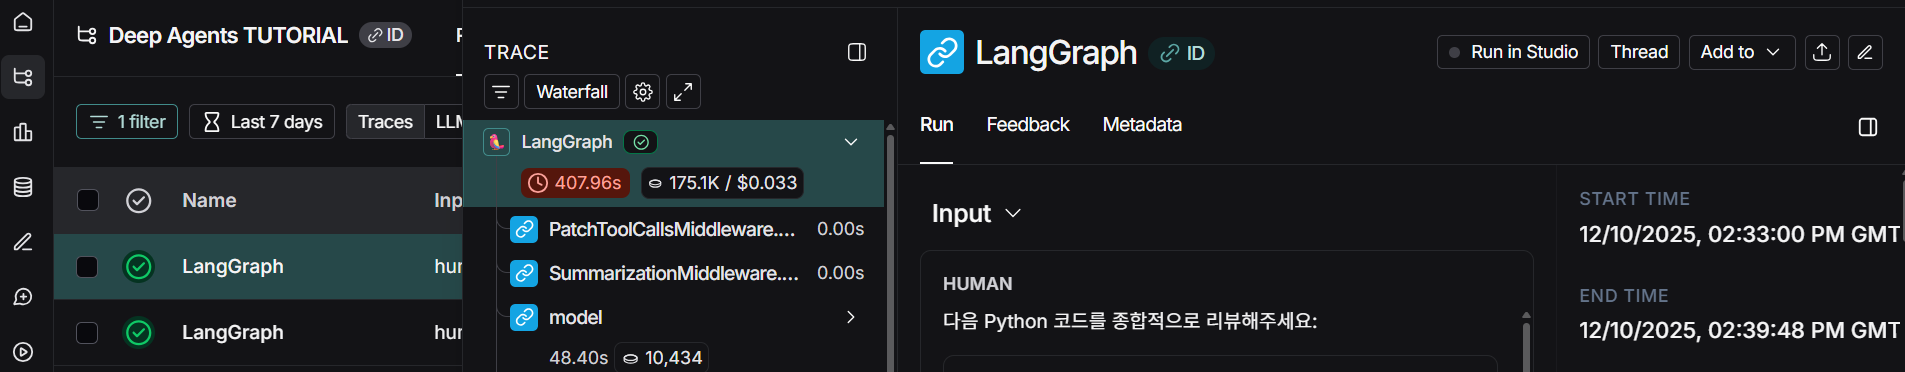

#### 생성된 파일 확인 

In [12]:
from langchain.messages import HumanMessage

# code_review_report.txt 파일 읽기 요청
read_file_request = """
/code_review_report.txt 파일의 내용을 읽어서 보여주세요.
"""

# Agent에게 파일 읽기 요청
response = code_review_coordinator.invoke(
    {"messages": [HumanMessage(content=read_file_request)]},
    config={"configurable": {"thread_id": "demo-files"}}
)


In [13]:
print(response["messages"][-1].content)

현재 요청하신 "/code_review_report.txt" 파일은 시스템에서 찾을 수 없습니다. 파일이 존재하지 않는 것 같아요.

다음 단계로 진행하려면 코드베이스를 공유해 주세요. 코드가 제공되면 제가 아래의 프로세스로 분석하고 최종 보고서를 작성하겠습니다.

작업 흐름 제안
- 1) 하위 전문가 호출
  - code_reviewer: 코드 품질, 가독성, 컨벤션, 로직 검토
  - security_expert: 보안 취약점, 데이터 노출 위험 등 보안 검토
  - performance_expert: 실행 시간, 메모리 효율성 및 최적화 방안
  - 이 세 전문가를 병렬로 실행해 피드백을 수집합니다.
- 2) 피드백 수렴 및 정리
  - 각 전문가의 핵심 피드백을 누락 없이 요약하고 서로 충돌하는 부분은 우선순위를 조정합니다.
- 3) 최종 개선 코드 제안
  - 사용자가 즉시 적용할 수 있도록, 패치 가능(diff) 형태의 최종 개선 코드와 함께 구체적 변경 사항을 제시합니다.
- 4) 최종 보고서 구성
  - 구성 예시(요약은 아래처럼 포함):
    - Executive Summary: 주요 이슈와 빠른 승리 포인트
    - Code Quality Radar: 가독성, 유지보수성, 테스트성, 견고성, 보안, 성능의 종합 점수 및 근거
    - Findings by Category: 범주별 핵심 이슈, 재현 방법, 위험도, 심각도
    - Patch-ready Improvements: 구체적인 코드 변경 제안 및 필요 시 부분 diffs/스니펫
    - Architecture Review: 모듈 간 경계, 의존성, 확장성에 대한 피드백
    - Testing & Documentation: 테스트 커버리지, 문서화 상태와 개선점
    - Roadmap & Quick Wins: 시급도에 따른 우선순위 로드맵
    - Appendix: 도구 설정 제안(린터, 타입체커, 포맷터, 보안 스캐너 등)

필요한 입력 정보
- 코드베이스 위치: Git 

## 4. CompiledSubAgent 방식

더 고급 사용 사례를 위해 미리 컴파일된 Agent를 Subagent로 사용할 수 있습니다.


### Dictionary vs CompiledSubAgent 비교

| 구분 | Dictionary 방식 | CompiledSubAgent 방식 |
|------|----------------|---------------------|
| **정의 방법** | 딕셔너리로 간단하게 정의 | `create_deep_agent()`로 미리 생성 |
| **코드 예시** | `{"name": "researcher", "description": "...", "system_prompt": "..."}` | `{"name": "researcher", "description": "...", "agent": create_deep_agent(...)}` |
| **웹 검색 가능** | ✅ 가능 (자동 도구 통합) | ✅ 가능 (자동 또는 명시적 지정) |
| **도구 커스터마이징** | ❌ 제한적 (자동 통합만 가능) | ✅ 완전한 제어 가능 |
| **설정 복잡도** | 🟢 낮음 (3개 필드만 필요) | 🟡 높음 (별도 agent 생성 필요) |
| **코드 양** | 🟢 적음 (5-10줄) | 🟡 많음 (15-20줄) |
| **적합한 사용 사례** | 간단한 역할 분담, 빠른 프로토타이핑 | 복잡한 워크플로우, 특정 도구 필요 시 |
| **도구 지정** | 자동 (환경 변수 기반) | 수동 가능 (`tools=[...]` 파라미터) |
| **재사용성** | 🟡 중간 (같은 dict 재사용) | 🟢 높음 (agent 객체 여러 곳에서 사용) |
| **성능** | 🟢 빠름 (런타임 생성) | 🟢 빠름 (미리 컴파일) |
| **디버깅** | 🟡 어려움 (내부 로직 숨겨짐) | 🟢 쉬움 (명시적 설정 확인 가능) |

### Subagent by Deep Agent 정의

독립적인 전문 Agent들을 먼저 생성

#### 정보를 검색하고 조사하는 전문가

In [14]:
from langchain_tavily import TavilySearch

search_ai_web = TavilySearch(
    max_results=3,
    topic="news",               # 또는 "news", "finance" 등
    include_answer=True,           # 답변 포함 여부
    include_raw_content=False,     # 원본 내용 포함 여부
    include_images=False,          # 이미지 포함 여부
    search_depth="advanced",          # "basic" 또는 "advanced"
    include_domains=[
        "https://huggingface.co/papers",
        "https://huggingface.co/papers/trending",
        "https://www.futuretools.io/",
        "https://the-decoder.com/"
    ],
    exclude_domains=None            # 필요하면 제외 도메인 지정 가능
)

In [15]:
researcher_expert = create_deep_agent(
    model=llm,
    tools=[search_ai_web],
    system_prompt="""
당신은 전문 연구원입니다.
- 주어진 주제에 대해 철저히 조사합니다
- 신뢰할 수 있는 출처를 찾습니다
- 수집한 정보를 요약하여 반환합니다
    """
)

#### 데이터 분석 전문가

In [16]:
analyst_expert = create_deep_agent(
    model=llm,
    system_prompt="""
당신은 데이터 분석 전문가입니다.
- 제공된 데이터를 분석합니다
- 패턴과 트렌드를 찾습니다
- 실행 가능한 인사이트를 제공합니다
    """
)

#### 전문적인 보고서를 작성하는 전문가

In [17]:
writer_expert = create_deep_agent(
    model=llm,
    system_prompt="""
당신은 전문 기술 작가입니다.
- 명확하고 구조화된 문서를 작성합니다
- 기술적 내용을 이해하기 쉽게 설명합니다
- 적절한 형식과 스타일을 사용합니다
    """
)

### Deep Agent with Subagents

In [18]:
from deepagents import create_deep_agent

# 이들을 Subagent로 사용하는 Main Agent 생성
analyst_coordinator = create_deep_agent(
    model=llm,
    checkpointer=checkpointer,
    system_prompt="""
당신은 프로젝트 매니저입니다.
복잡한 작업을 받으면 적절한 전문가에게 위임하세요:
- 정보 조사가 필요하면 researcher_expert
- 데이터 분석이 필요하면 analyst_expert 
- 문서 작성이 필요하면 writer_expert

각 전문가의 결과를 취합하여 최종 결과를 제공하세요.
    """,
    subagents=[
        {
            "name": "researcher_expert",
            "description": "웹에서 정보를 검색하고 조사하는 전문가입니다. 최신 정보가 필요할 때 이 agent를 호출하세요.",
            "runnable": researcher_expert
        },
        {
            "name": "analyst_expert", 
            "description": "데이터를 분석하고 인사이트를 도출하는 전문가입니다. 데이터 분석이 필요할 때 이 agent를 호출하세요.",
            "runnable": analyst_expert
        },
        {
            "name": "writer_expert",
            "description": "전문적인 보고서를 작성하는 전문가입니다. 문서 작성이 필요할 때 이 agent를 호출하세요.",
            "runnable": writer_expert
        }
    ]
)

print("Main Agent (with Subagents) 생성 완료!")

Main Agent (with Subagents) 생성 완료!


### Display

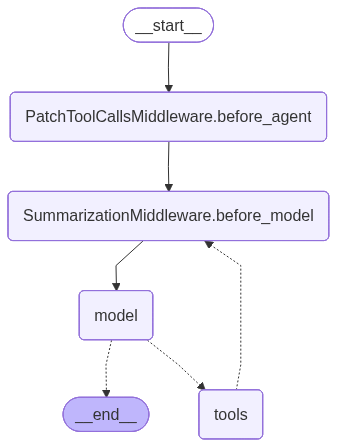

In [19]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            analyst_coordinator.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

### 테스트 


In [20]:
from langchain.messages import HumanMessage

# 복잡한 작업 요청
complex_task = """
다음 작업을 수행해주세요:

1. AI 에이전트의 2024년 주요 트렌드를 조사하세요
2. 수집한 정보에서 상위 3가지 트렌드를 분석하세요
3. 분석 결과를 바탕으로 'ai_trends_report.txt' 파일에 보고서를 작성하세요

보고서는 다음 섹션을 포함해야 합니다:
- 요약 (Executive Summary)
- 주요 트렌드 분석
- 시장 영향
- 결론 및 전망
"""

response = analyst_coordinator.invoke(
    {"messages": [HumanMessage(content=complex_task)]},
    config={"configurable": {"thread_id": "subagent-demo"}}
)

In [22]:
print("2024년 주요 트렌드를 조사 완료!")
print(response["messages"][-1].content)


2024년 주요 트렌드를 조사 완료!
완료되었습니다. 아래는 현재 ai_trends_report.txt에 반영된 보고서의 요약 및 주요 내용입니다. 파일 경로도 함께 안내드립니다.

파일 위치
- /ai_trends_report.txt

요약 및 주요 내용

1) 상위 3개 트렌드 (Executive Summary에 반영)
- Trend 1: Agentic AI and multi-agent autonomy becomes mainstream
  - 왜 중요한가: 하나의 에이전트가 아닌 다수의 에이전트를 조합해 목표를 달성하는 자율 시스템이 주류가 되며, 엔터프라이즈와 소비자 모두에서 복합 작업의 자동화를 가능하게 함.
  - 기업 영향: 기능 간 연계 자동화 증가, 의사결정 속도/정확성 향상, 거버넌스 및 보안 요구 증가.
  - 소비자 영향: 여러 앱/서비스를 아우르는 더 능력 있는 디지털 어시스턴트, 사용자 노력 감소.
  - 실무 시사점: 도구 간 오케스트레이션 필요, 안전 및 정책 레일 강화 필요.
  - 측정 지표: 다중 에이전트 작업 완료율, 목표 도달 시간, 오작동/코얼리션 관련 incident 수, 사용자 만족도.
  - 참고: researcher_expert 출력의 Trend 1.

- Trend 4: Tool use as a core capability with robust safety gatekeeping
  - 왜 중요한가: 실제 업무는 API/도구 호출을 필요로 하며, 도구 사용 단계의 안전성/거버넌스를 계획에 반영해야 함.
  - 기업 영향: 엔터프라이즈 시스템과의 연계 자동화 강화, 데이터 접근 제어의 중요성 증가.
  - 소비자 영향: 개인정보 보호와 보안 제약을 지키며 서비스 및 기능 확장.
  - 실무 시사점: 안전한 도구 호출 패턴, 승인/롤백 파이프라인, 로깅/감사 추적, 장애 복구 메커니즘 필요.
  - 측정 지표: 도구 호출 성공률, 호출 지연시간, 차단/게이트된 도구 호출 수, 컴플라이언스 감사 지표.
  - 참고: re

#### [Langsmith](https://smith.langchain.com/)

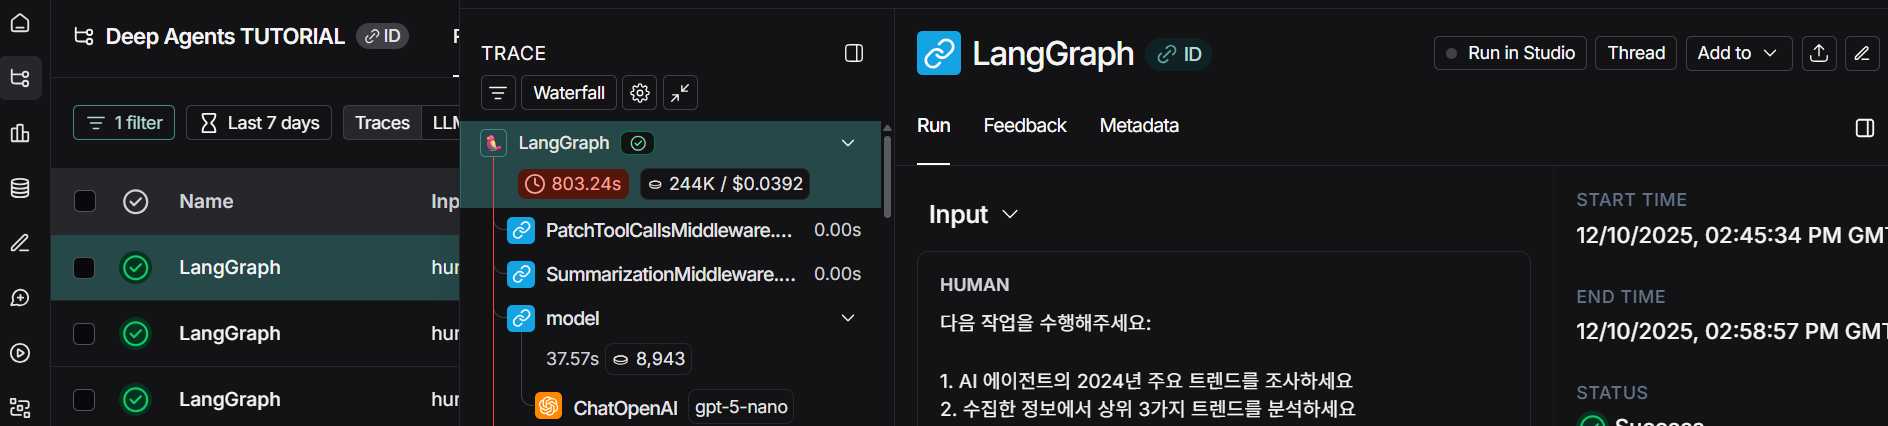

## 5. 주요 개념 정리

### Subagent 정의 방법 비교

#### 1. Dictionary-based Subagent

```python
{
    "name": "subagent_name",
    "description": "what this subagent does",
    "system_prompt": "detailed instructions"
}
```

**장점**: 간단하고 빠르게 정의 가능  
**단점**: 제한된 커스터마이징

#### 2. CompiledSubAgent

```python
{
    "name": "subagent_name",
    "description": "what this subagent does",
    "agent": create_deep_agent(...)  # 미리 생성된 Agent
}
```

**장점**: 완전한 제어, 복잡한 설정 가능  
**단점**: 더 많은 코드 필요

### Best Practices

1. **단일 책임 원칙**: 각 Subagent는 하나의 명확한 역할만 담당
2. **명확한 인터페이스**: description을 통해 Subagent의 역할을 명확히 정의
3. **순차적 처리**: Main Agent가 Subagent 간 작업 흐름을 관리
4. **결과 통합**: Main Agent가 각 Subagent의 결과를 취합
